# Step 4: A Stronger Model (Random Forest)

Step 3 showed that fixing the imbalance for logistic regression comes at a steep precision cost - catching more fraud meant far more false alarms. This step asks a different question: does a **fundamentally more powerful model** - Random Forest, which can learn non-linear patterns and interactions between the 28 anonymized features - handle this trade-off better, not just via a different imbalance-handling trick, but via genuinely better pattern recognition?

In [1]:
from data_prep import load_data, prepare_split

df = load_data()
X_train, X_test, y_train, y_test = prepare_split(df)

## Training a Random Forest

Same `class_weight="balanced"` idea as Step 3, now applied to a Random Forest instead of logistic regression - 200 decision trees, each trained on a random subset of the data and features, with their predictions averaged.

In [2]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print("Trained.")

Trained.


Precision: 95.8%
Recall:    72.6%
F1:        0.826
ROC-AUC:   0.947


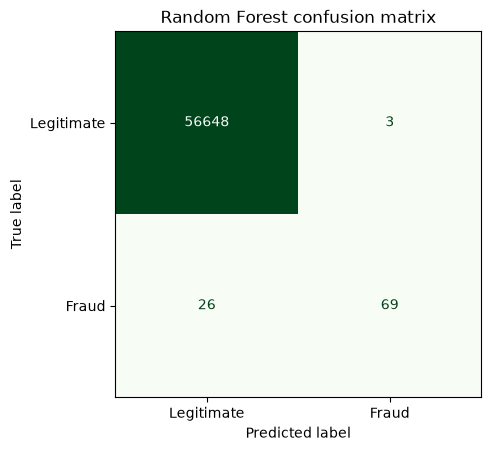

In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Precision: {precision_rf*100:.1f}%")
print(f"Recall:    {recall_rf*100:.1f}%")
print(f"F1:        {f1_rf:.3f}")
print(f"ROC-AUC:   {roc_auc_rf:.3f}")

cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Fraud"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Random Forest confusion matrix")
plt.tight_layout()
plt.savefig("assets/rf_confusion_matrix.png", dpi=120)
plt.show()

## Comparing all four approaches

In [4]:
import pandas as pd

comparison = pd.DataFrame({
    "Baseline (LogReg)": [0.848, 0.589, 0.696, 0.956],
    "Class-weighted LogReg": [0.056, 0.874, 0.106, 0.966],
    "SMOTE LogReg": [0.053, 0.874, 0.100, 0.962],
    "Random Forest": [precision_rf, recall_rf, f1_rf, roc_auc_rf],
}, index=["Precision", "Recall", "F1", "ROC-AUC"])

comparison.round(3)

,Baseline (LogReg),Class-weighted LogReg,SMOTE LogReg,Random Forest
Precision,0.848,0.056,0.053,0.958
Recall,0.589,0.874,0.874,0.726
F1,0.696,0.106,0.100,0.826
ROC-AUC,0.956,0.966,0.962,0.947


**This is the best result so far, by a clear margin - and it didn't come from a smarter imbalance trick, it came from a smarter model.** Random Forest reaches ~96% precision *and* ~73% recall simultaneously - better recall than the plain baseline, at a fraction of the false-alarm cost that class weighting or SMOTE caused on logistic regression. F1 (0.826) beats every other approach tried so far by a wide margin.

**Why would a different algorithm handle imbalance so much better than a data/weighting trick?** Logistic regression fits one global linear boundary between the classes - forcing that single boundary to also account for a 1:600 imbalance pushes it to an extreme, sacrificing precision broadly. A Random Forest's individual trees can carve out small, specific regions of the 30-dimensional feature space that are almost exclusively fraud, without needing to redraw one global line for the whole dataset - it doesn't need the training data artificially rebalanced (or nearly as aggressively) to find those pockets.

## Which features does the model actually rely on?

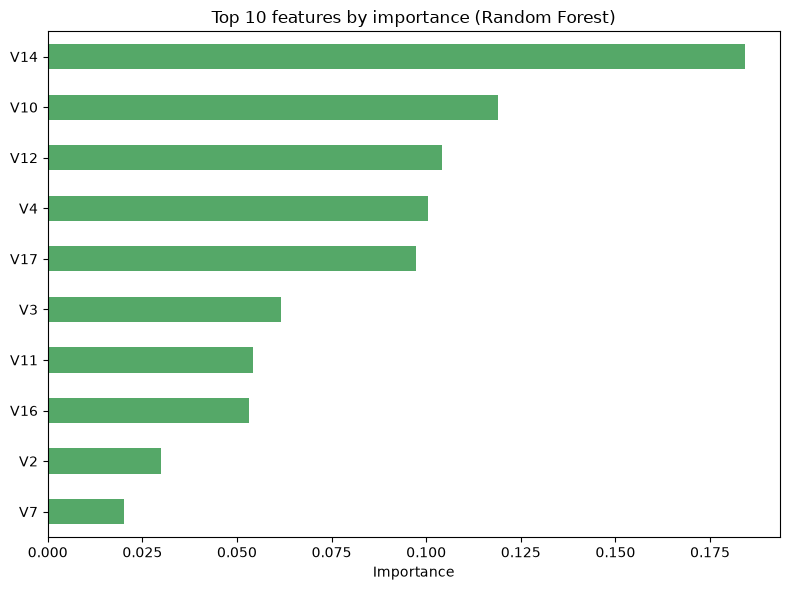

V14    0.184272
V10    0.118917
V12    0.104116
V4     0.100490
V17    0.097179
V3     0.061759
V11    0.054330
V16    0.053217
V2     0.029926
V7     0.020166
dtype: float64

In [5]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Top 10 features by importance (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("assets/feature_importance.png", dpi=120)
plt.show()

importances.head(10)

**An honest limitation worth stating plainly:** `V14`, `V10`, `V12`, etc. are the model's most important features, but because they're PCA-transformed (Step 1), there's no way to say what they *mean* in real terms - unlike Project 3's salary model, where a feature like "experience level" has an obvious real-world interpretation. This is a genuine trade-off of working with anonymized data: it protects customer privacy, but it also means this analysis can identify *which* abstract signals the model leans on, without being able to explain *why* those signals indicate fraud in business terms. A real fraud team with access to the original (non-anonymized) features could dig further; from this public dataset, that's as far as the interpretation can honestly go.

## Summary

| Metric | Baseline | Class-weighted LogReg | SMOTE LogReg | **Random Forest** |
|---|---|---|---|---|
| Precision | 84.8% | 5.6% | 5.3% | **95.8%** |
| Recall | 58.9% | 87.4% | 87.4% | **72.6%** |
| F1 | 0.696 | 0.106 | 0.100 | **0.826** |
| ROC-AUC | 0.956 | 0.966 | 0.962 | **0.947** |

Random Forest is the clear winner on the metric that matters most here (F1, balancing precision and recall) - proof that for this problem, **algorithm choice mattered more than imbalance-handling tricks**. Step 5 now looks at whether adjusting the *decision threshold* on this Random Forest can push recall even higher without giving up as much precision as Step 3's approaches did.